In [1]:
import numpy as np 
import pandas as pd 

In [2]:
try: 
    df = pd.read_csv('wine.csv')
except FileNotFoundError:
    print('File not found.')

In [3]:
print(f'Data Shape: {df.shape[0]} Row, {df.shape[1]} Column')
print("\n--- First 5 Lines ---")
display(df.head())

Data Shape: 6497 Row, 13 Column

--- First 5 Lines ---


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
print('/n---- Data Types and Memory Usage ----')
print(df.info())

print('/n---- Missing Value (NaN) Numbers ----')
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print('/n---- Unique Value Numbers ----')
print(df.nunique())

/n---- Data Types and Memory Usage ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None
/n---- Missing Val

In [5]:
print(f'---- Statical Summary of Numarical Variables -----')
display(df.describe().T)

---- Statical Summary of Numarical Variables -----


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6487.0,7.216579,1.296750,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6489.0,0.339691,0.164649,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6494.0,0.318722,0.145265,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6495.0,5.444326,4.758125,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6495.0,0.056042,0.035036,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6488.0,3.218395,0.160748,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6493.0,0.531215,0.148814,0.22000,0.43000,0.51000,0.60000,2.00000


In [6]:
IQR = (
    df.select_dtypes(include='number')
      .quantile(0.75)
    -
    df.select_dtypes(include='number')
      .quantile(0.25)
)

print(IQR)

fixed acidity            1.30000
volatile acidity         0.17000
citric acid              0.14000
residual sugar           6.30000
chlorides                0.02700
free sulfur dioxide     24.00000
total sulfur dioxide    79.00000
density                  0.00465
pH                       0.21000
sulphates                0.17000
alcohol                  1.80000
quality                  1.00000
dtype: float64


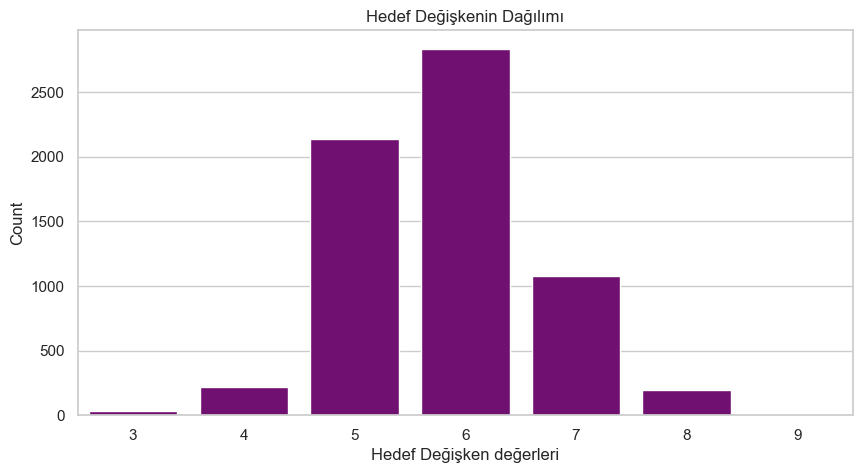

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 5))

sns.countplot(x=df['quality'], color='purple')
plt.title('Hedef Değişkenin Dağılımı')
plt.xlabel('Hedef Değişken değerleri')
plt.ylabel('Count')
plt.show()

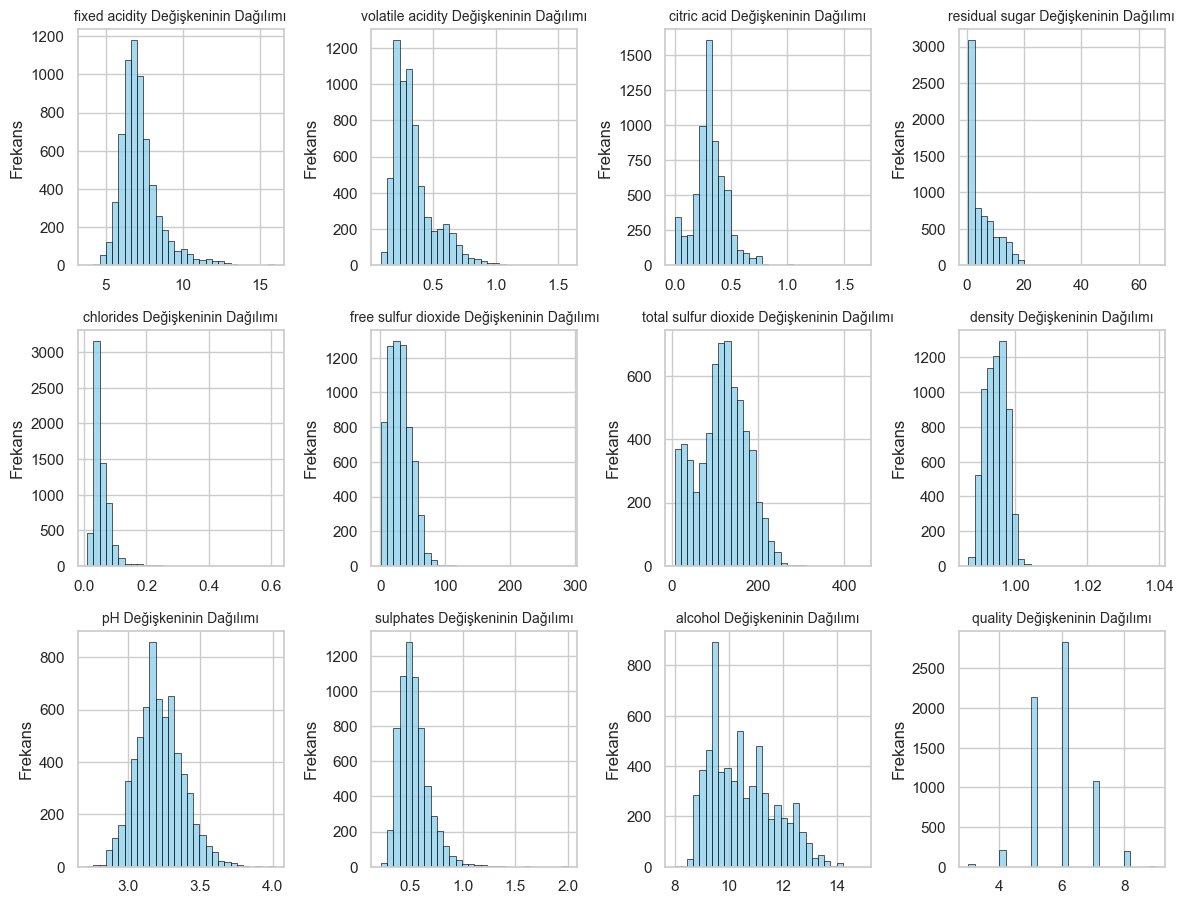

In [8]:
# Sayısal sütunları seç
sayisal_kolonlar = df.select_dtypes(
    include=['int64', 'float64']
).columns

# Grafik boyutu
plt.figure(figsize=(12, len(sayisal_kolonlar) * 3))

# Her sütun için histogram
for i, col in enumerate(sayisal_kolonlar, 1):

    plt.subplot(len(sayisal_kolonlar), 4, i)

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        color='skyblue',
        edgecolor='black'
    )

    plt.title(
        f'{col} Değişkeninin Dağılımı',
        fontsize=10
    )

    plt.xlabel('')
    plt.ylabel('Frekans')

plt.tight_layout()
plt.show()

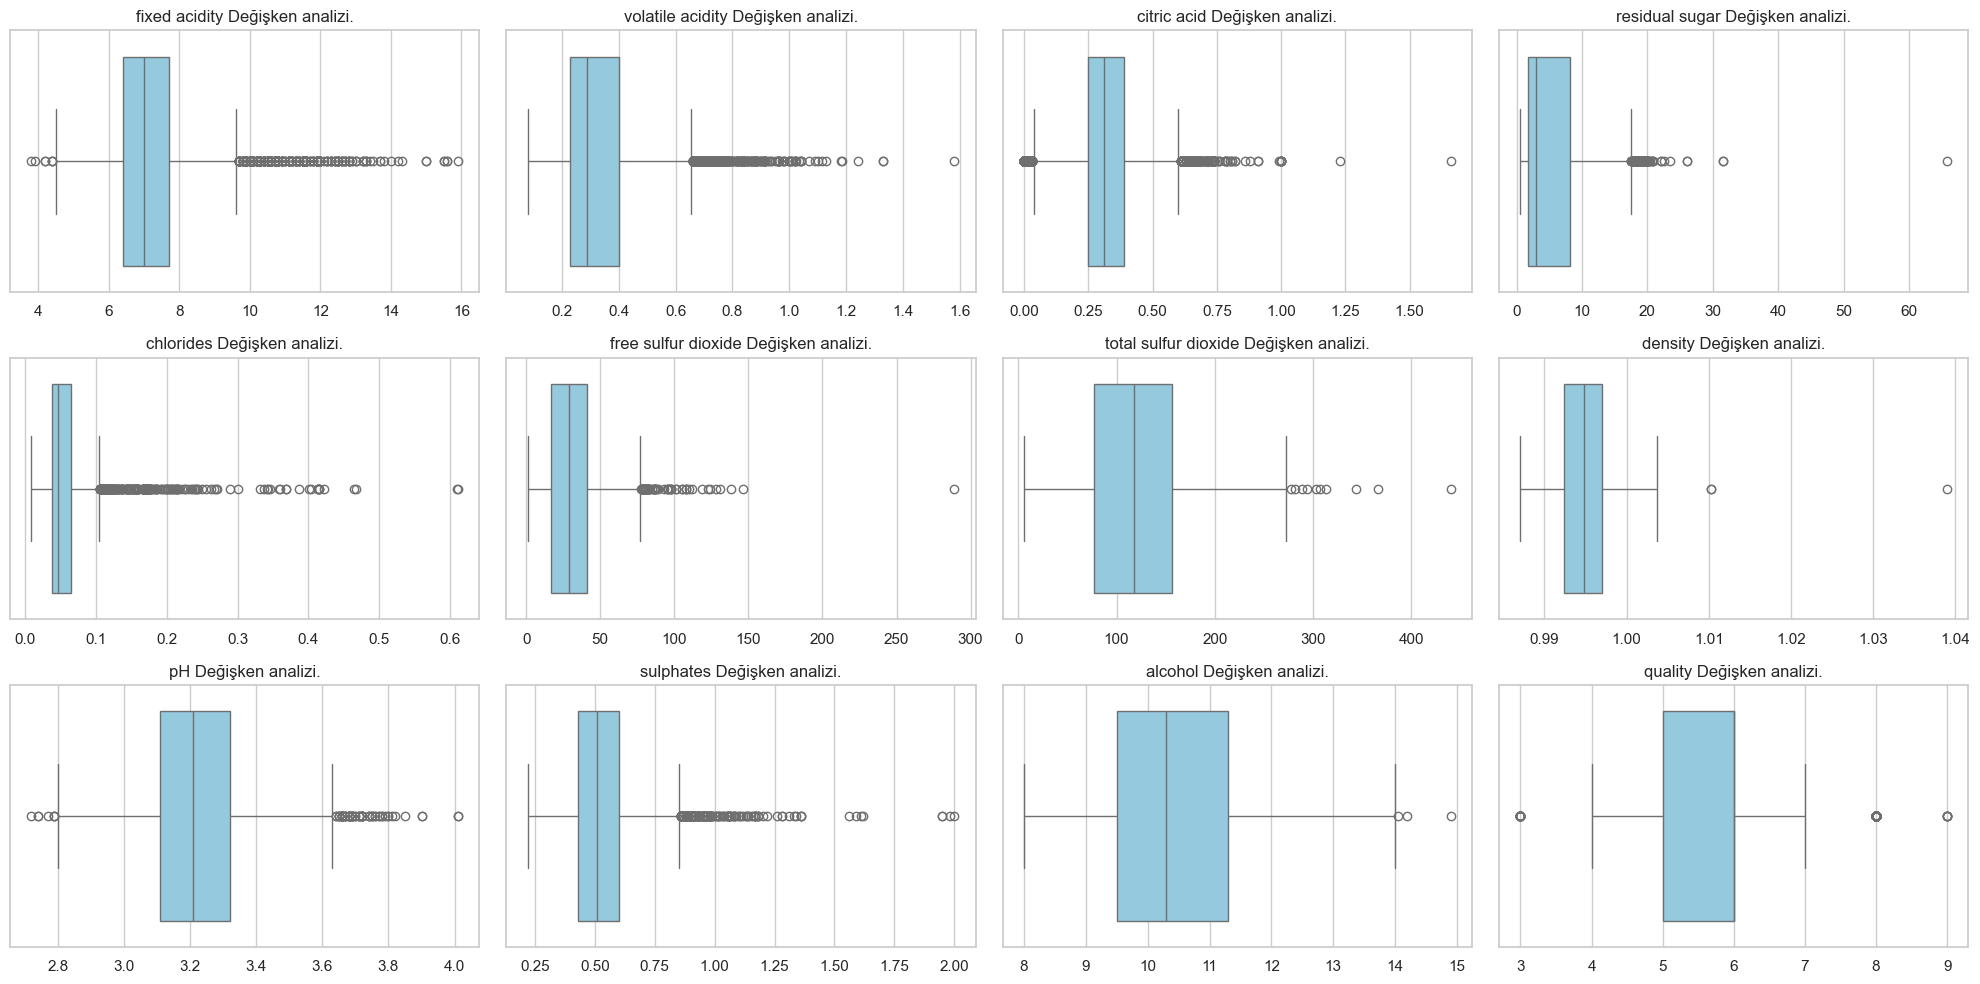

In [9]:
plt.figure(figsize=(20, 10))
for i, col in enumerate(sayisal_kolonlar, start=1):
    plt.subplot(3, 4, i)
    sns.boxplot(x = df[col], color='skyblue')
    plt.title(f'{col} Değişken analizi.')
    plt.xlabel('')
plt.tight_layout()
plt.show()


aykırı değer içeren değişkenler : pH, sulphates, free sulfur dioxide, chlorides, residual sugar, volatilite acidity, fixed acidity

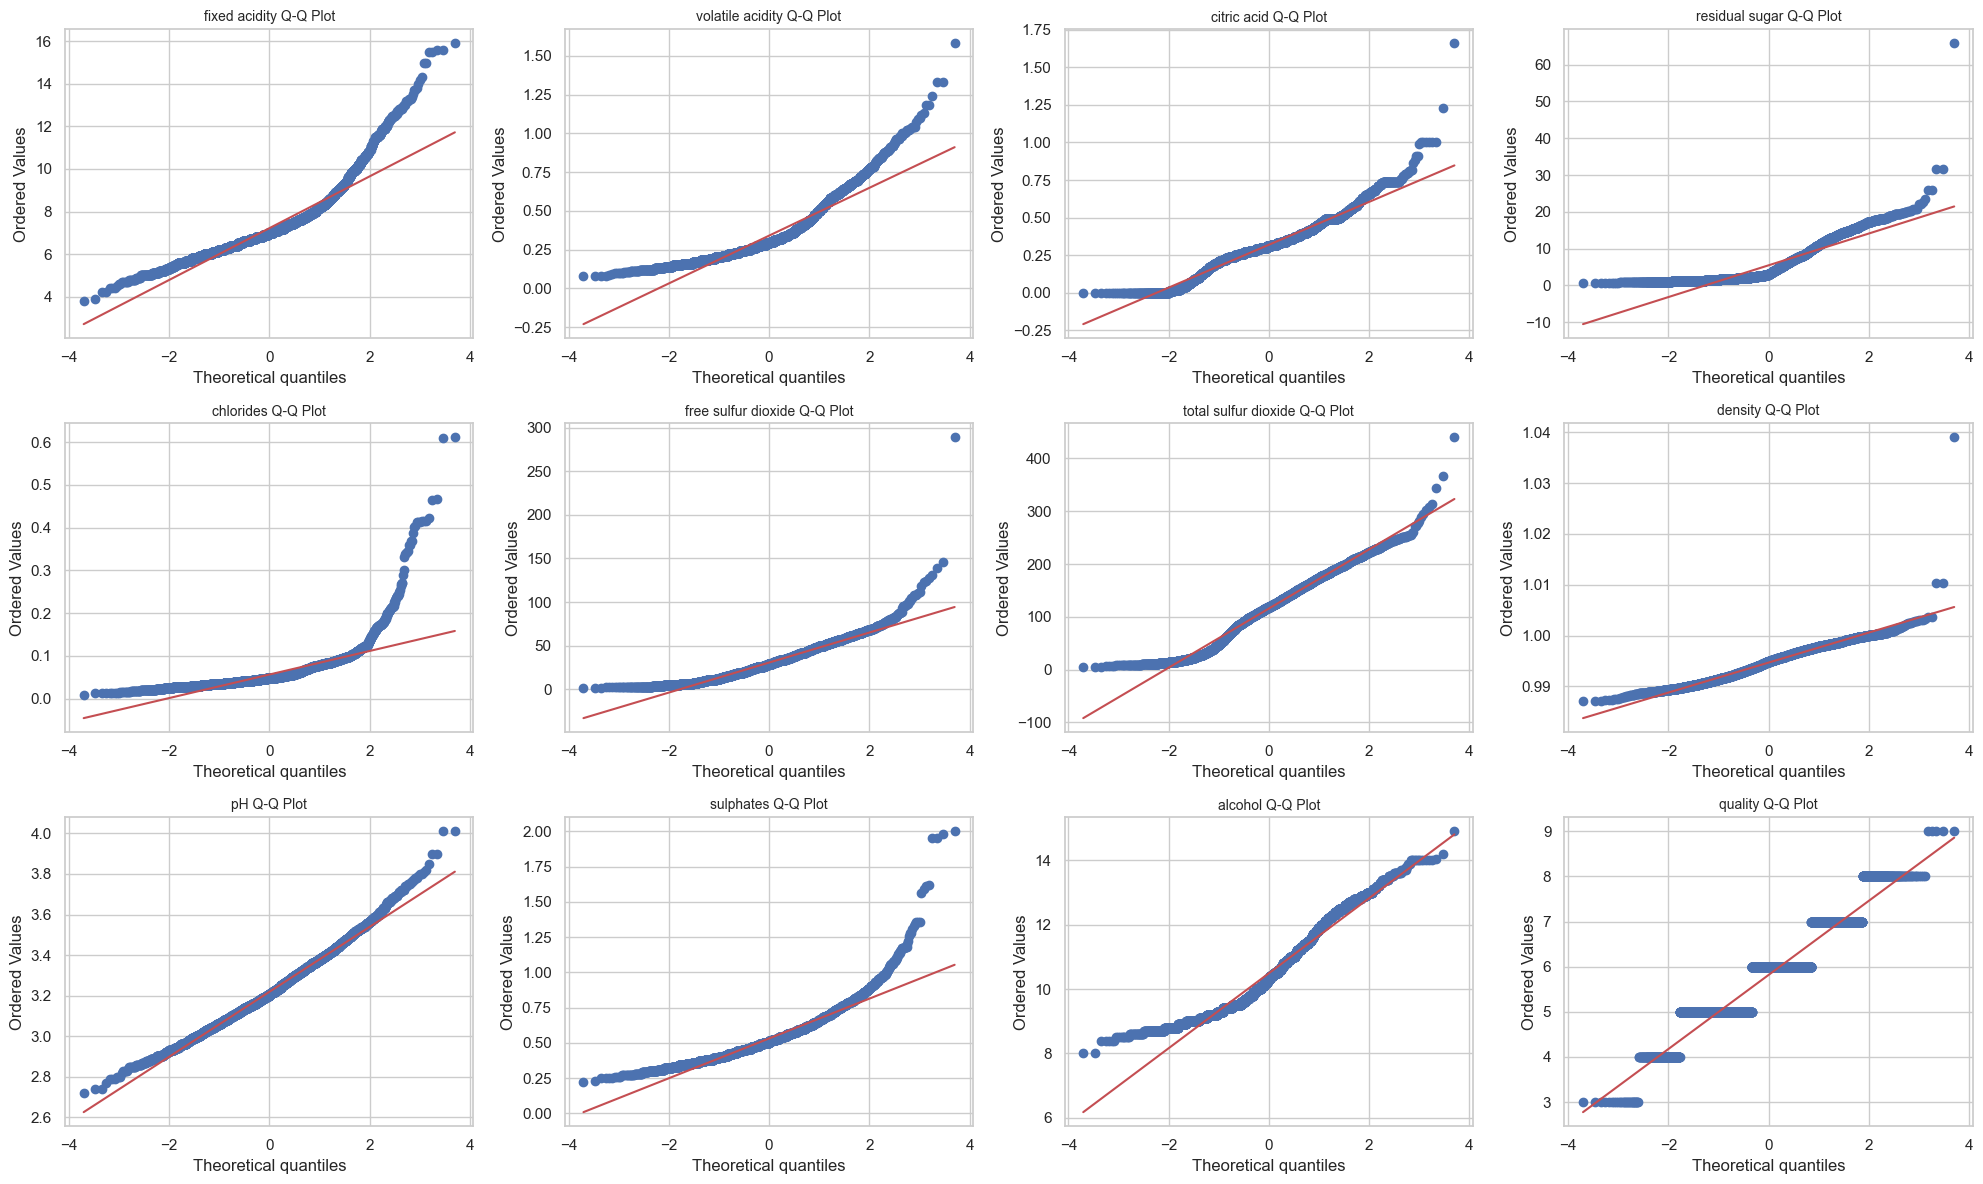

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

sayisal_kolonlar = df.select_dtypes(
    include=['int64', 'float64']
).columns

n_cols = 4
n_rows = int(
    np.ceil(len(sayisal_kolonlar) / n_cols)
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5*n_cols, 4*n_rows)
)

axes = axes.ravel()

for i, col in enumerate(sayisal_kolonlar):

    stats.probplot(
        df[col].dropna(),
        dist='norm',
        plot=axes[i]
    )

    axes[i].set_title(
        f'{col} Q-Q Plot',
        fontsize=10
    )

# Boş kalan eksenleri sil
for j in range(
    len(sayisal_kolonlar),
    len(axes)
):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['quality'])
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape : {X_test.shape} | y_test shape : {y_test.shape}")

X_train shape: (5197, 12) | y_train shape: (5197,)
X_test shape : (1300, 12) | y_test shape : (1300,)


In [12]:
medyan_kolonlari = ['fixed acidity', 'volatile acidity', 'citric acid', 
                     'residual sugar', 'chlorides', 'sulphates']

for col in medyan_kolonlari:
    train_median = X_train[col].median() # Değeri SADECE train'den öğreniyoruz
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col] = X_test[col].fillna(train_median) # Testi de train medyanı ile dolduruyoruz

# Dengeli/Simetrik sütun (pH) için ORTALAMA (Mean) seçiyoruz
train_pH_mean = X_train['pH'].mean()
X_train['pH'] = X_train['pH'].fillna(train_pH_mean)
X_test['pH'] = X_test['pH'].fillna(train_pH_mean)

In [13]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='if_binary', sparse_output=False, dtype=int)

type_train_encoded = ohe.fit_transform(X_train[['type']])

type_test_encoded = ohe.transform(X_test[['type']])

X_train['type_encoded'] = type_train_encoded
X_test['type_encoded'] = type_test_encoded

X_train = X_train.drop(columns=['type'])
X_test = X_test.drop(columns=['type'])

In [14]:
from sklearn.preprocessing import PowerTransformer,RobustScaler, OneHotEncoder

sert_carpik_kolonlar = ['residual sugar', 'chlorides', 'free sulfur dioxide', 
                        'total sulfur dioxide', 'volatile acidity', 'fixed acidity', 
                        'citric acid', 'sulphates']

pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_train[sert_carpik_kolonlar] = pt.fit_transform(X_train[sert_carpik_kolonlar])
X_test[sert_carpik_kolonlar] = pt.transform(X_test[sert_carpik_kolonlar])

dengeli_outlier_kolonlar = ['pH', 'density', 'alcohol']

scaler = RobustScaler()
X_train[dengeli_outlier_kolonlar] = scaler.fit_transform(X_train[dengeli_outlier_kolonlar])
X_test[dengeli_outlier_kolonlar] = scaler.transform(X_test[dengeli_outlier_kolonlar])

In [15]:
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (5197, 12) | X_test shape: (1300, 12)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble  import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest' : RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"=== {name} Sınıflandırma Başarısı ===")
print(f"Accuracy (Doğruluk Oranı): {acc:.4f}")
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred))
print("Karmaşıklık Matrisi (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))
print("-" * 40 + "\n")

=== Random Forest Sınıflandırma Başarısı ===
Accuracy (Doğruluk Oranı): 0.7085

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       1.00      0.15      0.26        46
           5       0.74      0.78      0.76       420
           6       0.68      0.80      0.74       579
           7       0.71      0.53      0.61       221
           8       0.88      0.22      0.35        32

    accuracy                           0.71      1300
   macro avg       0.67      0.41      0.45      1300
weighted avg       0.72      0.71      0.69      1300

Karmaşıklık Matrisi (Confusion Matrix):
[[  0   0   2   0   0   0]
 [  0   7  27  11   1   0]
 [  0   0 328  90   2   0]
 [  0   0  83 462  33   1]
 [  0   0   5  99 117   0]
 [  0   0   1  13  11   7]]
----------------------------------------



c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo